# Insights for a single alpha value
This Jupyter notebook exxplores different insights for a run over the course of one week with alpha value X

### Imports

In [5]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import gzip
import json
import folium
import numpy as np

### Loading the data

In [6]:
# Configuration
results_dir_root = Path('../../simulation_results/TD full week')  # For TD_test_instance files

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

alpha_value = 0.5

#vehicle_df = pd.read_csv('/Users/minasjovik/Projects/FOMOsim/policies/sjovik_sund/simulation_results/sjovik_sund_alphas_TD_0612252103_seed_1_full_week_0.400_results_vehicle_visits_seed_1.csv')
#vehicle_df = pd.read_csv('/Users/minasjovik/Projects/FOMOsim/policies/sjovik_sund/simulation_results/sjovik_sund_alphas_TD_0612252103_seed_1_full_week_0.500_results_vehicle_visits_seed_1.csv')
vehicle_df = pd.read_csv('/Users/minasjovik/Projects/FOMOsim/policies/sjovik_sund/simulation_results/sjovik_sund_alphas_TD_0612252103_seed_1_full_week_0.200_results_vehicle_visits_seed_1.csv')

#hourly_data = pd.read_csv('/Users/minasjovik/Library/CloudStorage/OneDrive-NTNU/master/FOMOsim/policies/sjovik_sund/simulation_results/TD full week/sjovik_sund_alphas_TD_0612252103_seed_1_full_week_0.400_results_hourly_seed_1.csv')
#hourly_data = pd.read_csv('/Users/minasjovik/Library/CloudStorage/OneDrive-NTNU/master/FOMOsim/policies/sjovik_sund/simulation_results/TD full week/sjovik_sund_alphas_TD_0612252103_seed_1_full_week_0.500_results_hourly_seed_1.csv')
hourly_data = pd.read_csv('/Users/minasjovik/Projects/FOMOsim/policies/sjovik_sund/simulation_results/sjovik_sund_alphas_TD_0612252103_seed_1_full_week_0.200_results_hourly_seed_1.csv')

#station_hourly_activity_df = pd.read_csv('/Users/minasjovik/Library/CloudStorage/OneDrive-NTNU/master/FOMOsim/policies/sjovik_sund/simulation_results/TD full week/sjovik_sund_alphas_TD_0612252103_seed_1_full_week_0.400_results_station_hourly_seed_1.csv')
station_hourly_activity_df = pd.read_csv('/Users/minasjovik/Projects/FOMOsim/policies/sjovik_sund/simulation_results/sjovik_sund_alphas_TD_0612252103_seed_1_full_week_0.200_results_station_hourly_seed_1.csv')

# Load station data
with gzip.open("/Users/minasjovik/Projects/FOMOsim/instances/TD_W34_old.json.gz", "rt") as f:   # adjust path if needed
    data = json.load(f)

# data["stations"] is a list of dicts
stations_df = pd.DataFrame(data["stations"])

# Split the 'location' list into separate columns
stations_df[["lat", "lon"]] = stations_df["location"].apply(pd.Series)

alpha_summary = hourly_data.agg(
        {
            "Maintenance Time (minutes)": "sum",
            "Maintenance Violations": "sum",
            "Maintenance Starvations": "sum",
            "Starvations": "sum",
            "Bike Pickups": "sum",
            "Bike Deliveries": "sum",
        }
    ).reset_index()

print(alpha_summary.to_string(index=False))


                     index       0
Maintenance Time (minutes) 1800.18
    Maintenance Violations  997.00
   Maintenance Starvations 4138.00
               Starvations 4412.00
              Bike Pickups  850.00
           Bike Deliveries  850.00


## Congestions vs Bike starvations

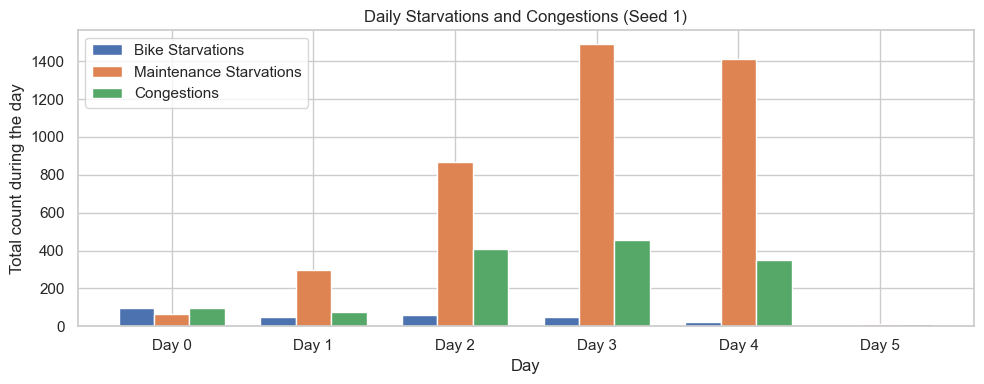

In [7]:
import numpy as np
import matplotlib.pyplot as plt

daily = ( hourly_data.groupby(["Seed", "Day"]) 
         .agg({ "Bike Starvations": "sum", "Long Congestions": "sum", "Short Congestions": "sum", "Maintenance Starvations": "sum" }) 
         .reset_index() ) # Total congestions per day 

daily["Congestions"] = daily["Long Congestions"]

# === PLOT PER SEED: 3 bars side-by-side per DAY ===
for seed, g in daily.groupby("Seed"):
    
    # DAY (unique days only)
    days = g["Day"].values
    
    bike_starv  = g["Bike Starvations"].values
    maint_starv = g["Maintenance Starvations"].values
    cong        = g["Long Congestions"].values + g["Short Congestions"].values
    
    x = np.arange(len(days))   # 0,1,2,... positions
    width = 0.25               # narrower bars

    plt.figure(figsize=(10,4))

    plt.bar(x - width, bike_starv,  width=width, label="Bike Starvations")
    plt.bar(x,         maint_starv, width=width, label="Maintenance Starvations")
    plt.bar(x + width, cong,        width=width, label="Congestions")

    plt.xlabel("Day")
    plt.ylabel("Total count during the day")
    plt.title(f"Daily Starvations and Congestions (Seed {seed})")

    plt.xticks(x, [f"Day {d}" for d in days])
    plt.legend()
    plt.tight_layout()
    plt.show()


# Maintenance time allocation as function of time

/var/folders/yq/llblptc118lf6wvmlzl8550r0000gn/T/ipykernel_75508/3319740715.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hourly_data = hourly_data.groupby("Seed", group_keys=False).apply(add_ma)


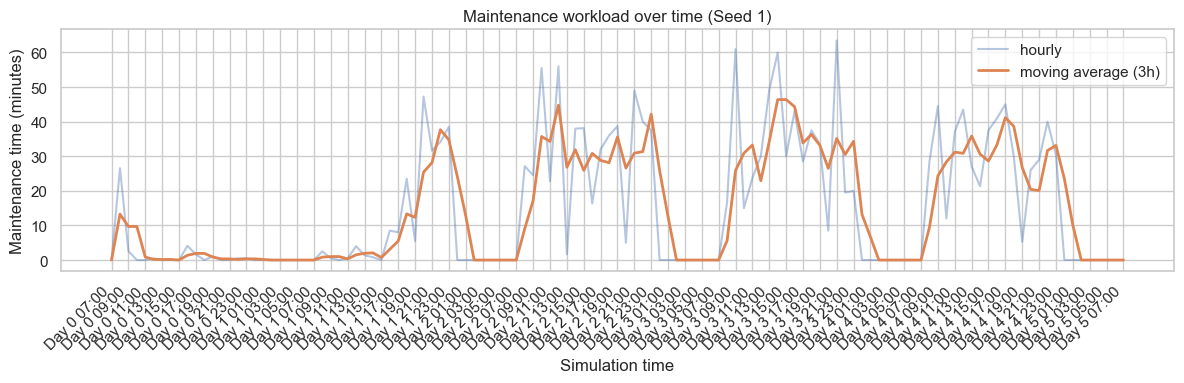

In [8]:
hourly_data = hourly_data.sort_values(["Seed", "Time (minutes)"])

# === MOVING AVERAGE, per seed (3-hour window since data is hourly) ===
def add_ma(group):
    m = group["Maintenance Time (minutes)"]
    group["Maintenance_MA"] = m.rolling(window=3, min_periods=1).mean()
    return group

hourly_data = hourly_data.groupby("Seed", group_keys=False).apply(add_ma)

# === HUMAN-READABLE LABELS: "Day d HH:00" ===
hourly_data["label"] = (
    "Day " + hourly_data["Day"].astype(str)
    + " " + hourly_data["Hour"].astype(str).str.zfill(2) + ":00"
)

# === PLOT FOR EACH SEED ===
for seed, g in hourly_data.groupby("Seed"):

    x = g["Time (minutes)"]  # numeric x-axis

    plt.figure(figsize=(12, 4))
    plt.plot(x, g["Maintenance Time (minutes)"], alpha=0.4, label="hourly")
    plt.plot(x, g["Maintenance_MA"], linewidth=2, label="moving average (3h)")

    plt.ylabel("Maintenance time (minutes)")
    plt.xlabel("Simulation time")
    plt.title(f"Maintenance workload over time (Seed {seed})")

    # x-axis labels every 3rd point (avoid clutter)
    step = 2
    xticks = x.iloc[::step]
    xlabels = g["label"].iloc[::step]
    plt.xticks(xticks, xlabels, rotation=45, ha="right")

    plt.legend()
    plt.tight_layout()
    plt.show()

## Time spent on maintenance vs rebalancing
In this the number of pick ups and drop offs are multiplied by the average time spent on such action, 3 minutes.

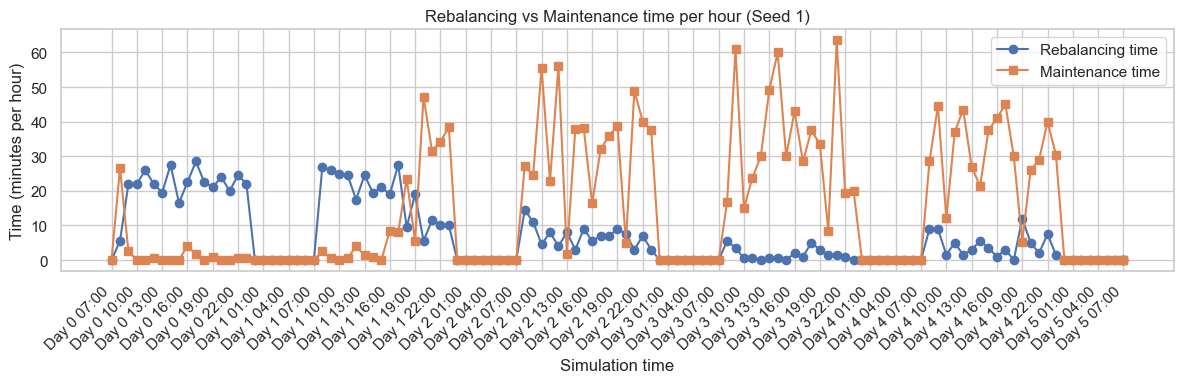

In [9]:
hourly_data["Rebalancing Time (minutes)"] = (hourly_data["Bike Pickups"] + hourly_data["Bike Deliveries"]) * 0.5

# === HUMAN-READABLE LABELS: "Day d HH:00" ===
hourly_data["label"] = (
    "Day " + hourly_data["Day"].astype(str)
    + " " + hourly_data["Hour"].astype(str).str.zfill(2) + ":00"
)

# === PLOT FOR EACH SEED ===
for seed, g in hourly_data.groupby("Seed"):

    x = g["Time (minutes)"]  # numeric x-axis

    plt.figure(figsize=(12, 4))
    plt.plot(x, g["Rebalancing Time (minutes)"], marker="o", label="Rebalancing time")
    plt.plot(x, g["Maintenance Time (minutes)"], marker="s", label="Maintenance time")

    plt.ylabel("Time (minutes per hour)")
    plt.xlabel("Simulation time")
    plt.title(f"Rebalancing vs Maintenance time per hour (Seed {seed})")

    # x-axis labels every 3rd point (avoid clutter)
    step = 3 if len(g) > 10 else 1
    xticks = x.iloc[::step]
    xlabels = g["label"].iloc[::step]
    plt.xticks(xticks, xlabels, rotation=45, ha="right")

    plt.legend()
    plt.tight_layout()
    plt.show()



# Vehicle visit statistics

In [10]:
station_counts = (
    vehicle_df["Station ID"]
    .value_counts()
    .reset_index()
)
station_counts.columns = ["Station ID", "num_visits"]

station_counts.head(70)

,Station ID,num_visits
0,S30,18
1,S54,17
2,S63,15
3,S42,14
4,S44,14
...,...,...
57,S25,1
58,S51,1
59,S12,1
60,S24,1


In [11]:
# visits_df already loaded
# stations_df already loaded from JSON

# Extract numeric id: "S35" → 35
vehicle_df["id"] = vehicle_df["Station ID"].str.extract(r"S(\d+)").astype(int)

# Count visits per station id
station_counts = (
    vehicle_df
        .groupby("id")
        .size()
        .reset_index(name="num_visits")
)

# Join on integer id
stations_with_visits = stations_df.merge(station_counts, on="id", how="left")

# Fill stations that never appear in visits
stations_with_visits["num_visits"] = stations_with_visits["num_visits"].fillna(0).astype(int)

stations_with_visits.head(70)


,id,location,is_depot,capacity,num_bikes,leave_intensities,leave_intensities_stdev,arrive_intensities,arrive_intensities_stdev,move_probabilities,lat,lon,num_visits
0,0,"[63.40772802863199, 10.39705323440262]",False,21,10,"[[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.2, 0.8, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.400000000000...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.4, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.8000000...","[[[0.014925373134328358, 0.014925373134328358,...",63.407728,10.397053,6
1,1,"[63.414746566093925, 10.397386363673064]",False,15,7,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.2, 0.4, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.4000000000000001,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.6, 0.0, 0.2,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.4000000000000001,...","[[[0.014925373134328358, 0.014925373134328358,...",63.414747,10.397386,7
2,2,"[63.436025749373755, 10.430998463879718]",False,24,12,"[[0.0, 0.0, 0.0, 0.0, 0.2, 1.8, 0.4, 0.2, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.4000000000000001, 2.22...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.400000000000...","[[[0.014925373134328358, 0.014925373134328358,...",63.436026,10.430998,4
3,3,"[63.42126270770024, 10.386516005020496]",False,18,8,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.6, 0.4, 0.0, 0.4,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.7999999999999999,...","[[0.0, 0.0, 0.0, 0.0, 0.2, 1.4, 1.6, 0.2, 1.0,...","[[0.0, 0.0, 0.0, 0.0, 0.4000000000000001, 1.95...","[[[0.014925373134328358, 0.014925373134328358,...",63.421263,10.386516,3
4,4,"[63.43337733865644, 10.401074857528158]",False,18,8,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.8, 1.0, 0.6,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.4000000000000001,...","[[0.0, 0.0, 0.0, 0.0, 0.2, 2.2, 0.8, 1.2, 0.2,...","[[0.0, 0.0, 0.0, 0.0, 0.4000000000000001, 2.31...","[[[0.014925373134328358, 0.014925373134328358,...",63.433377,10.401075,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,62,"[63.427896581278105, 10.403341750766884]",False,26,13,"[[0.0, 0.0, 0.0, 0.0, 0.0, 1.8, 2.8, 1.8, 1.2,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 1.8330302779823362,...","[[0.0, 0.0, 0.0, 0.0, 0.2, 1.0, 1.2, 1.4, 1.2,...","[[0.0, 0.0, 0.0, 0.0, 0.4000000000000001, 1.54...","[[[0.014925373134328358, 0.014925373134328358,...",63.427897,10.403342,9
63,63,"[63.42994558007871, 10.391905842869932]",False,28,14,"[[0.0, 0.0, 0.0, 0.0, 0.0, 1.2, 2.0, 1.0, 1.8,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 1.1661903789690602,...","[[0.0, 0.0, 0.0, 0.0, 0.2, 0.8, 3.0, 1.6, 3.2,...","[[0.0, 0.0, 0.0, 0.0, 0.4000000000000001, 0.74...","[[[0.014925373134328358, 0.014925373134328358,...",63.429946,10.391906,15
64,64,"[63.43527713641004, 10.405813604593277]",False,13,6,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.8, 0.6,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.400000000000...","[[0.0, 0.0, 0.0, 0.0, 0.0, 1.4, 1.0, 0.0, 0.6,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 1.4966629547095764,...","[[[0.014925373134328358, 0.014925373134328358,...",63.435277,10.405814,10
65,65,"[63.43660495943216, 10.425844341516495]",False,25,13,"[[0.0, 0.0, 0.0, 0.0, 1.6, 5.4, 1.2, 1.0, 0.4,...","[[0.0, 0.0, 0.0, 0.0, 1.854723699099141, 2.576...","[[0.0, 0.0, 0.0, 0.0, 0.2, 0.4, 0.0, 0.4, 1.0,...","[[0.0, 0.0, 0.0, 0.0, 0.4000000000000001, 0.48...","[[[0.014925373134328358, 0.014925373134328358,...",63.436605,10.425844,13


## Intensities of where the vehicle visits

In [12]:
def visit_color(n):
    if n >= 10:
        return "red"
    elif n >= 5:
        return "orange"
    else:
        return "blue"



# Center map on mean lat/lon of all stations
center_lat = stations_with_visits["lat"].mean()
center_lon = stations_with_visits["lon"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

# (optional) show all stations, or only top N
#top_stations = stations_with_visits.sort_values("num_visits", ascending=False).head(50)
top_stations = stations_with_visits  # <- all
print(top_stations["num_visits"].head(70))

max_visits = top_stations["num_visits"].max()
min_radius = 1
max_radius = 18 if max_visits > 0 else 6

for _, row in top_stations.iterrows():
    n = row["num_visits"]
    # scale radius with visits, but keep within a nice range
    radius = min_radius if max_visits == 0 else (
        min_radius + (n / max_visits) * (max_radius - min_radius)
    )

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=radius,
        fill=True,
        color=visit_color(n),
        fill_color=visit_color(n),
        fill_opacity=0.8,
        popup=f"Station S{row['id']}<br>Visits: {n}",
    ).add_to(m)

m.save("trondheim_map.html")

0      6
1      7
2      4
3      3
4      6
      ..
62     9
63    15
64    10
65    13
66     6
Name: num_visits, Length: 67, dtype: int64


## Average criticality over all stations

In [13]:

# Extract numeric station id from "S0", "S1", ...
station_hourly_activity_df["id"] = (
    station_hourly_activity_df["Station ID"]
    .astype(str)
    .str.extract(r"S(\d+)")
    .astype(int)
)

# --- Compute per-row share of capacity that is broken ---
# guard against capacity = 0 just in case
station_hourly_activity_df["broken_share"] = (
    station_hourly_activity_df["Unusable Bikes"] /
    station_hourly_activity_df["Capacity"].replace(0, np.nan)
)

# ---------------------------
# Average maintenance criticality AND avg % broken per station
# ---------------------------
crit_per_station = (
    station_hourly_activity_df
    .groupby("id", as_index=False)
    .agg(
        avg_maint_crit=("Avg Maintenance Criticality", "mean"),
        avg_broken_share=("broken_share", "mean")   # this is 0–1
    )
)

# Merge with coordinates from stations_df (must already have lat/lon)
stations_crit = stations_df.merge(crit_per_station, on="id", how="left")
stations_crit["avg_maint_crit"] = stations_crit["avg_maint_crit"].fillna(0.0)
stations_crit["avg_broken_share"] = stations_crit["avg_broken_share"].fillna(0.0)

center_lat = stations_crit["lat"].mean()
center_lon = stations_crit["lon"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

# simple color mapping based on maintenance criticality
def crit_color(c):
    if c >= 0.6:
        return "red"
    elif c >= 0.5:
        return "orange"
    elif c >= 0.4:
        return "yellow"
    else:
        return "green"

for _, row in stations_crit.iterrows():
    c = row["avg_maint_crit"]
    broken_pct = row["avg_broken_share"] * 100  # turn into %

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=6,  # could also scale with broken_pct if you like
        fill=True,
        fill_opacity=0.8,
        color=crit_color(c),
        fill_color=crit_color(c),
        popup=(
            f"Station S{row['id']}<br>"
            f"Avg maint. criticality: {c:.3f}<br>"
            f"Avg broken: {broken_pct:.1f}% of capacity"
        ),
    ).add_to(m)

m.save("station_criticality_map.html")


## Average fleet criticality

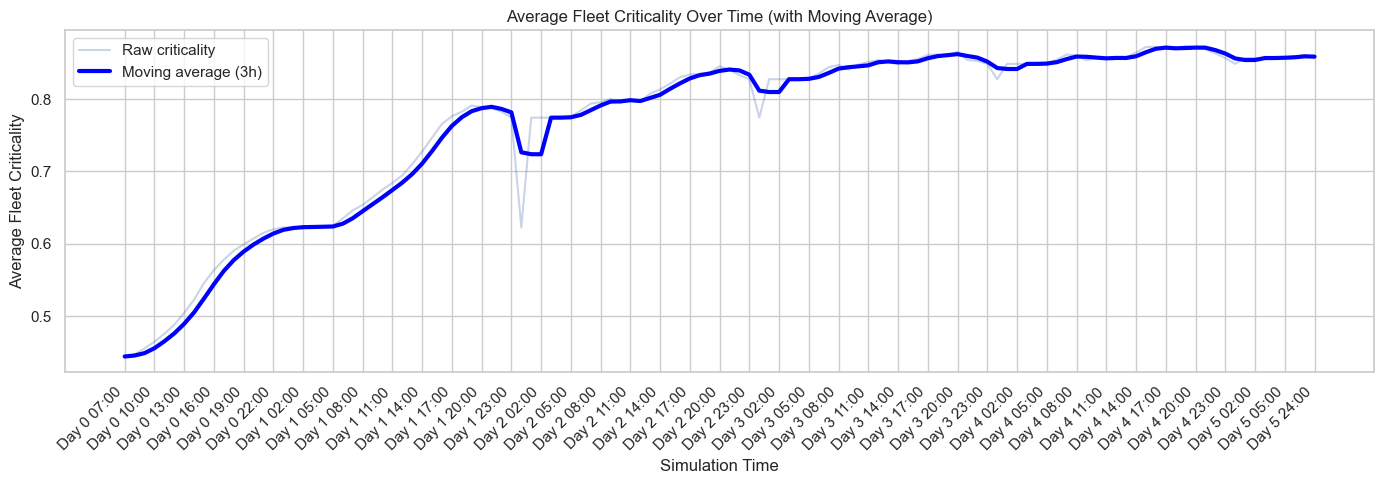

In [14]:
# === AVERAGE ACROSS SEEDS PER HOUR ===
crit = hourly_data.groupby(["Day", "Hour"], as_index=False)["Avg Bike Criticality"].mean()

# === MOVING AVERAGE SMOOTHING ===
# window=3 → 3-hour window. Change to 5 or 7 for smoother curves.
window = 3
crit["MA"] = crit["Avg Bike Criticality"].rolling(window=window, min_periods=1).mean()

# === BUILD READABLE X-AXIS LABELS ===
crit["label"] = (
    "Day " + crit["Day"].astype(str)
    + " " + crit["Hour"].astype(str).str.zfill(2) + ":00"
)

# Use simple integer x-axis for plotting
x = range(len(crit))

# === PLOT ===
plt.figure(figsize=(14,5))

# Faint raw values for context
plt.plot(x, crit["Avg Bike Criticality"], alpha=0.3, label="Raw criticality")

# Smoothed moving average line
plt.plot(x, crit["MA"], linewidth=3, color="blue", label=f"Moving average ({window}h)")

plt.ylabel("Average Fleet Criticality")
plt.xlabel("Simulation Time")
plt.title("Average Fleet Criticality Over Time (with Moving Average)")

# X-axis labels every few points for readability
step = 3 if len(crit) > 10 else 1
plt.xticks(
    ticks=[i for i in x][::step],
    labels=crit["label"].iloc[::step],
    rotation=45, 
    ha="right"
)

plt.legend()
plt.tight_layout()
plt.show()

##